In [14]:
import numpy as np
import pandas as pd 
import torch 
import random
import os
from IPython.display import SVG

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU
    
    # Force the use of deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For PyTorch 2.x+ (Handles scatter/gather ops)
    torch.use_deterministic_algorithms(True)
    
    # Crucial for GNNs: some scatter operations need an extra flag
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" 

seed_everything(42)

In [2]:
%cd ..

from utils.graph_constructor import smiles_to_graph, get_mol
from utils.molecule_visuzlizer import visualize_molecule

%cd ./notebooks/

/home/pulkit/personal/programming/code/Python/bbbp graph classification


/home/pulkit/miniconda3/envs/pytorch-geometric/lib/python3.12/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /home/pulkit/miniconda3/envs/pytorch-geometric/lib/python3.12/site-packages/libpyg.so
  import torch_geometric.typing


/home/pulkit/personal/programming/code/Python/bbbp graph classification/notebooks


In [4]:
molecule_net_data = pd.read_csv("../data/BBBP.csv").loc[:, ['smiles', 'p_np']]
molecule_net_data = molecule_net_data.rename(columns = {
  'smiles': 'smiles', 
  'p_np': 'label'
})

molecule_net_data

,smiles,label
0,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1
...,...,...
2045,C1=C(Cl)C(=C(C2=C1NC(=O)C(N2)=O)[N+](=O)[O-])Cl,1
2046,[C@H]3([N]2C1=C(C(=NC=N1)N)N=C2)[C@@H]([C@@H](...,1
2047,[O+]1=N[N](C=C1[N-]C(NC2=CC=CC=C2)=O)C(CC3=CC=...,1
2048,C1=C(OC)C(=CC2=C1C(=[N+](C(=C2CC)C)[NH-])C3=CC...,1


In [5]:
b3d8_data = pd.read_csv("../data/B3DB_classification_extended.tsv.gz", sep = '\t')
b3d8_data = b3d8_data.loc[:, ['SMILES', 'BBB+/BBB-']]

/tmp/ipykernel_88352/2918529894.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  b3d8_data = pd.read_csv("../data/B3DB_classification_extended.tsv.gz", sep = '\t')


In [6]:
b3d8_data['label'] = np.where(b3d8_data['BBB+/BBB-'] == 'BBB+', 1, 0) 
b3d8_data = b3d8_data.drop('BBB+/BBB-', axis =1)
b3d8_data = b3d8_data.rename(columns = {
  'SMILES': 'smiles', 
  'label': 'label'
})

In [7]:
data = pd.concat([molecule_net_data, b3d8_data], axis = 0) 
data

,smiles,label
0,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1
...,...,...
7802,c1ccc(CN(CC2=NCCN2)c2ccccc2)cc1,0
7803,CCOCCn1c(N2CCCN(C)CC2)nc2ccccc21,1
7804,CN1CCC(=C2c3ccccc3CC(=O)c3sccc32)CC1,1
7805,Cc1[nH]c(=O)c(C#N)cc1-c1ccncc1,0


In [8]:
data = data.drop_duplicates(['smiles'])

In [9]:
positive_samples = data[data['label'] == 1].shape[0] 
negative_samples = data[data['label'] == 0].shape[0] 

pos_weight = negative_samples / (positive_samples +negative_samples)

In [16]:
sample_smile, sample_label = data['smiles'].iloc[1], data['label'].iloc[1]

[07:27:26] Initializing Normalizer
[07:27:26] Running Normalizer


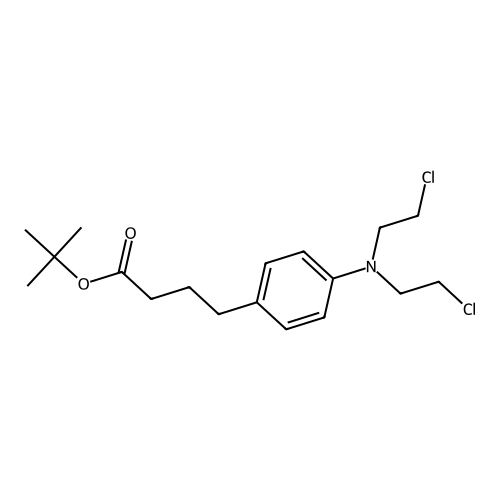

In [17]:
SVG(visualize_molecule(get_mol(sample_smile)))